Silakan upload file Gambar (.jpg atau .png):


Saving MBG.jpg to MBG.jpg


/tmp/ipykernel_15197/2872263764.py:29: RuntimeWarning: overflow encountered in scalar add
  c = 255.0 / np.log(1 + np.max(img_gray))
/tmp/ipykernel_15197/2872263764.py:29: RuntimeWarning: divide by zero encountered in log
  c = 255.0 / np.log(1 + np.max(img_gray))


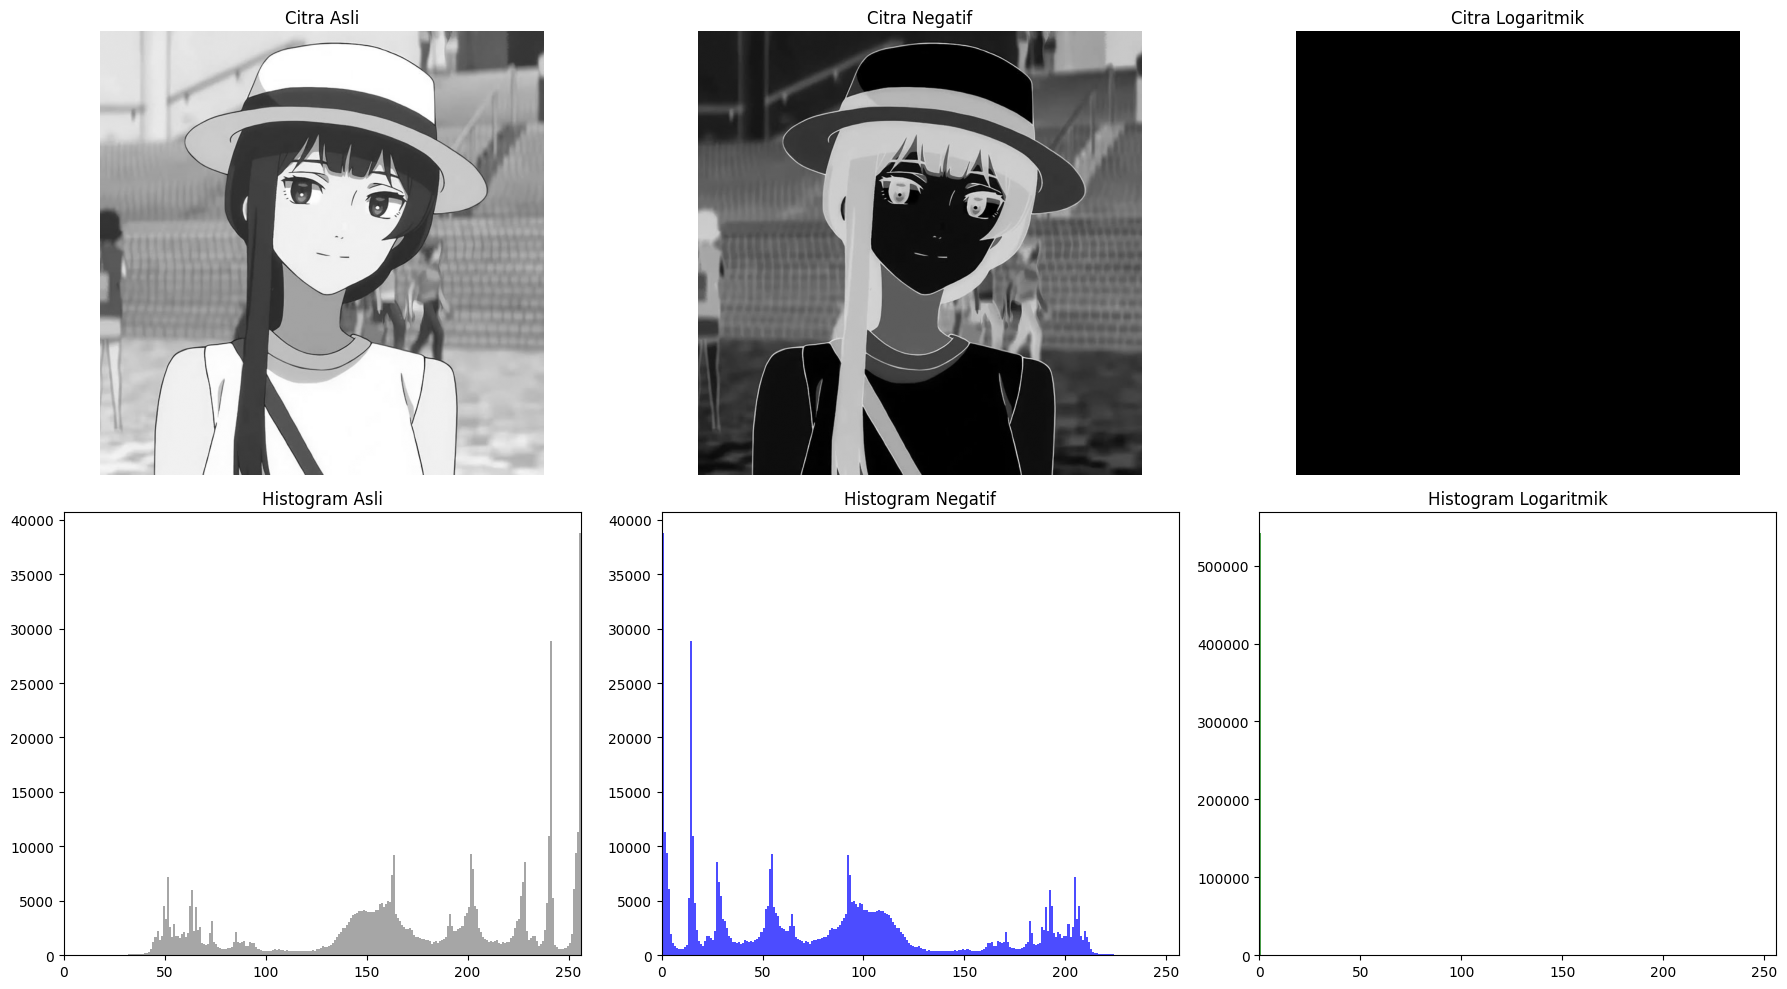

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 1. Mengunggah citra dari komputer lokal ke Google Colab
print("Silakan upload file Gambar (.jpg atau .png):")
uploaded = files.upload()

# Mengambil nama file yang baru saja diupload
filename = next(iter(uploaded))

# 2. Membaca citra dan mengubah citra menjadi grayscale
# Membaca data byte sebagai array numpy, lalu decode menjadi citra
img_array = np.frombuffer(uploaded[filename], np.uint8)
img_bgr = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

# Mengubah citra menjadi grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 3. Menerapkan Transformasi Negatif
# Rumus: G = 255 - F
img_negative = 255 - img_gray

# 4. Menerapkan Transformasi Logaritmik
# Rumus: G = c * log(1 + F)
# c = 255 / log(1 + max(F))
# Menggunakan tipe float32 agar tidak terjadi overflow saat perhitungan logaritma
c = 255.0 / np.log(1 + np.max(img_gray))
img_log_float = c * np.log(1 + img_gray.astype(np.float32))

# Mengubah kembali tipe data ke uint8 untuk keperluan visualisasi gambar
img_log = np.array(img_log_float, dtype=np.uint8)

# 5. Menampilkan hasil citra dan histogramnya dalam satu figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Baris pertama: Visualisasi Citra ---
axes[0, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Citra Asli")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_negative, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title("Citra Negatif")
axes[0, 1].axis('off')

axes[0, 2].imshow(img_log, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title("Citra Logaritmik")
axes[0, 2].axis('off')

# --- Baris kedua: Visualisasi Histogram ---
axes[1, 0].hist(img_gray.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
axes[1, 0].set_title("Histogram Asli")
axes[1, 0].set_xlim([0, 256])

axes[1, 1].hist(img_negative.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
axes[1, 1].set_title("Histogram Negatif")
axes[1, 1].set_xlim([0, 256])

axes[1, 2].hist(img_log.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
axes[1, 2].set_title("Histogram Logaritmik")
axes[1, 2].set_xlim([0, 256])

plt.tight_layout()
plt.show()